在训练过程中加入更多的控制

1. 训练中保存/保存最好的模型
2. 早停 
3. 训练过程可视化

<font color="red">注</font>: 使用 tensorboard 可视化需要安装 tensorflow (TensorBoard依赖于tensorflow库，可以任意安装tensorflow的gpu/cpu版本)

```shell
pip install tensorflow
```

In [152]:
# Import
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

In [153]:
print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 1.26.4
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu


In [154]:
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cpu


# 数据准备

In [155]:
from torchvision import datasets
from torchvision.transforms import ToTensor

# fashion_mnist图像分类数据集，衣服分类，60000张训练图片，10000张测试图片
train_ds = datasets.FashionMNIST(
    root='data',  # 数据集存放的位置
    train=True,  # 训练集
    transform=ToTensor(),  # 数据变换
    download=True  # 下载数据集
)

test_ds = datasets.FashionMNIST(
    root='data',
    train=False,
    transform=ToTensor(),
    download=True
)

# torchvision 数据集里没有提供训练集和验证集的划分
# 当然也可以用 torch.utils.data.Dataset 实现人为划分

# 从数据集到dataloader
在PyTorch中，`DataLoader`是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。`DataLoader`主要负责以下几个方面：

1. **批量加载数据**：`DataLoader`可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。

2. **数据打乱**：默认情况下，`DataLoader`会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。

3. **多线程数据加载**：`DataLoader`支持多线程（通过参数`num_workers`）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。

4. **数据预处理**：`DataLoader`可以与`transforms`结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。

5. **内存管理**：`DataLoader`负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。

6. **易用性**：`DataLoader`提供了一个简单的接口，可以很容易地集成到训练循环中。

In [156]:
batch_size = 32
train_lorder = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_lorder = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False)
#batch_size分批，shuffle洗牌

In [157]:
# 查看数据
for data, labels in train_lorder:
    print(data.shape, labels.shape)
    break

for data, labels in val_lorder:
    print(data.shape, labels.shape)
    break

torch.Size([32, 1, 28, 28]) torch.Size([32])
torch.Size([32, 1, 28, 28]) torch.Size([32])


# 定义模型

In [158]:
class NeuralNetwork(nn.Module):
    def __init__(self, layer_number=2):
        super().__init__()  # 继承父类的初始化方法，子类有父类的属性
        self.flatten = nn.Flatten()  # 将输入的多维张量展平为一维向量
        self.linear_relu_stack = nn.Sequential(  # 定义神经网络的层结构，包括线性层和激活函数ReL
            nn.Linear(28 * 28, 300),  # 第一个全连接层：输入维度为28*28(784)，输出维度为300
            nn.ReLU(),  # ReLU激活函数，引入非线性
            nn.Linear(300, 100),  # 第二个全连接层：输入维度为300，输出维度为100
            nn.ReLU(),
            nn.Linear(100, 10),  # 输出层：输入维度为100，输出维度为10(对应10个类
        )

    def forward(self, x):  # 定义前向传播方法
        # x.shape = [batch_size, 1, 28, 28]
        x = self.flatten(x)
        # 展平后 x.shape = [batch_size, 28 * 28]
        logits = self.linear_relu_stack(x)
        # 输出 logits.shape = [batch_size, 10]
        return logits  # 没有经过softmax

In [159]:
model = NeuralNetwork()

## 查看网络结构

In [160]:
model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU()
    (2): Linear(in_features=300, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [161]:
# 计算参数数量
784 * 300 + 300 + 300 * 100 + 100 + 100 * 10 + 10  #即模型中所有可训练参数的个数，乘以参数的元素个数，然后求和

266610

In [162]:
for name, param in model.named_parameters():  # 打印模型参数
    print(name, param.shape)

linear_relu_stack.0.weight torch.Size([300, 784])
linear_relu_stack.0.bias torch.Size([300])
linear_relu_stack.2.weight torch.Size([100, 300])
linear_relu_stack.2.bias torch.Size([100])
linear_relu_stack.4.weight torch.Size([10, 100])
linear_relu_stack.4.bias torch.Size([10])


In [163]:
# 查看模型参数
list(model.parameters())  # 这种方法拿到模型的所有可学习参数,requires_grad=True

[Parameter containing:
 tensor([[ 0.0340, -0.0304, -0.0216,  ..., -0.0109, -0.0033, -0.0220],
         [-0.0309, -0.0188,  0.0076,  ..., -0.0043,  0.0138,  0.0220],
         [-0.0032,  0.0067,  0.0345,  ...,  0.0262, -0.0306,  0.0117],
         ...,
         [ 0.0114, -0.0049, -0.0329,  ..., -0.0280,  0.0178,  0.0264],
         [-0.0079, -0.0144,  0.0236,  ...,  0.0276, -0.0047,  0.0356],
         [ 0.0204,  0.0319,  0.0013,  ...,  0.0320,  0.0285,  0.0238]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.0066,  0.0059, -0.0120, -0.0025,  0.0101, -0.0224,  0.0018, -0.0099,
         -0.0144,  0.0066, -0.0083, -0.0347,  0.0093,  0.0325,  0.0211, -0.0110,
          0.0116, -0.0265, -0.0052, -0.0267,  0.0188, -0.0161, -0.0211, -0.0297,
          0.0106, -0.0139,  0.0240, -0.0285,  0.0177,  0.0254, -0.0331, -0.0346,
         -0.0306,  0.0336,  0.0243, -0.0213, -0.0049, -0.0253, -0.0321,  0.0074,
         -0.0122,  0.0080,  0.0291,  0.0299, -0.0003,  0.0342, -0.0243, -0.0226

In [164]:
model.state_dict()  # 这种方法用于保存模型参数，看能看见参数属于模型的哪一部分

OrderedDict([('linear_relu_stack.0.weight',
              tensor([[ 0.0340, -0.0304, -0.0216,  ..., -0.0109, -0.0033, -0.0220],
                      [-0.0309, -0.0188,  0.0076,  ..., -0.0043,  0.0138,  0.0220],
                      [-0.0032,  0.0067,  0.0345,  ...,  0.0262, -0.0306,  0.0117],
                      ...,
                      [ 0.0114, -0.0049, -0.0329,  ..., -0.0280,  0.0178,  0.0264],
                      [-0.0079, -0.0144,  0.0236,  ...,  0.0276, -0.0047,  0.0356],
                      [ 0.0204,  0.0319,  0.0013,  ...,  0.0320,  0.0285,  0.0238]])),
             ('linear_relu_stack.0.bias',
              tensor([ 0.0066,  0.0059, -0.0120, -0.0025,  0.0101, -0.0224,  0.0018, -0.0099,
                      -0.0144,  0.0066, -0.0083, -0.0347,  0.0093,  0.0325,  0.0211, -0.0110,
                       0.0116, -0.0265, -0.0052, -0.0267,  0.0188, -0.0161, -0.0211, -0.0297,
                       0.0106, -0.0139,  0.0240, -0.0285,  0.0177,  0.0254, -0.0331, -0.0346,
    

# 训练模型
pytorch的训练需要自行实现，包括
1. 定义损失函数
2. 定义优化器
3. 定义训练步
4. 训练

In [165]:
# # 1.定义损失函数，使用交叉熵损失函数
# loss_fct = nn.CrossEntropyLoss()  #内部先做softmax，然后计算交叉熵
# # 2.定义优化器,使用SGD优化器
# optimizer = torch.optim.SGD(model.parameters(), lr=0.001,
#                             momentum=0.9)  # model.parameters()是所有可学习参数，lr是学习率，momentum是动量，用于加速训练
# # 优化器的作用是根据损失函数的梯度来更新参数，使得模型参数的梯度方向和损失函数的梯度方向一致，从而达到最小化损失函数的目的。

## 评估模型

In [166]:
# 评估模型
from sklearn.metrics import accuracy_score


@torch.no_grad()  # 装饰器，禁止反向传播，节省内存
def evaluator(model, dataloader, loss_fct):
    loss_list = []  # 记录损失
    pred_list = []  # 记录预测
    label_list = []  # 记录标签
    for data, label in dataloader:  #10000/32=312,
        # 转到GPU
        # data.shape [batch size, 1, 28, 28]
        # label.shape [batch size]
        data = data.to(device)
        label = label.to(device)

        # 前向传播
        logits = model(data)
        loss = loss_fct(logits, label)  # 验证集损失
        loss_list.append(loss.item())  # 记录损失 # tensor.item() 获取tensor的数值，loss是只有一个元素的tensor
        pred = logits.argmax(
            axis=-1)  # 验证集预测, axis=-1 表示最后一个维度,因为logits.shape [batch size, 10]，所以axis=-1表示对最后一个维度求argmax，即对每个样本的10个类别的概率求argmax，得到最大概率的类别, preds.shape [batch size]
        pred_list.extend(pred.cpu().numpy().tolist())  #将PyTorch张量转换为NumPy数组。只有当张量在CPU上时，这个转换才是合法的
        label_list.extend(label.cpu().numpy().tolist())  #将PyTorch张量转换为NumPy数组。只有当张量在CPU上时，这个转换才是合法的

        acc = accuracy_score(label_list, pred_list)  # 验证集准确率

        return np.mean(loss_list), acc  # 返回验证集平均损失和准确率

# TensorBoard 可视化

pip install tensorboard
训练过程中可以使用如下命令启动tensorboard服务。注意使用绝对路径，否则会报错

```shell
 tensorboard  --logdir="D:\BaiduSyncdisk\pytorch\chapter_2_torch\runs" --host 0.0.0.0 --port 8848
```

In [167]:
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    def __init__(self, log_dir, flush_secs=10):
        """
        SummaryWriter, log_dir是log存放路径，flush_secs是每隔多少秒写入磁盘        
        :param log_dir: dir to write log.
        :param flush_secs: write to dsk each flush_secs seconds. Defaults to 10.
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):  # 画模型结构
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))  # 画模型结构

    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
        )  # 画loss曲线, main_tag是主tag，tag_scalar_dict是子tag，global_step是步数

    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )  # 画acc曲线, main_tag是主tag，tag_scalar_dict是子tag，global_step是步数

    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        )  # 画lr曲线, main_tag是主tag，tag_scalar_dict是子tag，global_step是步数

    def __call__(self, step, **kwargs):
        # add loss,把loss，val_loss取掉，画loss曲线
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)  # 画loss曲线
        # add acc
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)  # 画acc曲线
        # add lr
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)  # 画lr曲线


# Save Best Model and Checkpoints 
根据验证集准确率保存最佳模型和检查点

In [168]:
class SaveCheckpointCallback:
    def __init__(self, save_dir, save_best_only=True, save_step=500):
        """
        Save checkpoints each save_epoch epoch. 
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.
        :param save_dir: dir to save model.
        :param save_best_only: save best model only. Defaults to True.
        :param save_step: save model checkpoint every save_step steps. Defaults to 500.
        """
        self.save_dir = save_dir  # 保存路径
        self.save_best_only = save_best_only  # 是否只保存最佳模型
        self.save_step = save_step  # 保存步数
        self.best_metric = -1  # 最好的指标，指标不可能为负数，所以初始化为-1

        # 如果不存在保存路径，则创建
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:  # 每隔save_step步保存一次模型
            return

        if self.save_best_only:
            assert metric is not None  # 必须传入acc
            if metric >= self.best_metric:
                # save best model
                self.best_metric = metric
                # 保存最好的模型，覆盖之前的模型，不保存step，只保存state_dict，即模型参数，不保存优化器参数
                torch.save(state_dict, os.path.join(self.save_dir, "best_model.ckpt"))
        else:
            # 保存每个step的模型，不覆盖之前的模型，保存step，保存state_dict，即模型参数，不保存优化器参数
            torch.save(state_dict, os.path.join(self.save_dir, f"model_{step}.ckpt"))


# Early Stop
提前停止训练

In [169]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """
        Early stop callback.
        :param patience: how many epochs to wait before stopping when loss is not improving. Defaults to 5.
        :param min_delta: minimum change in the monitored quantity to qualify as an improvement. Defaults to 0.01.
        """
        self.patience = patience  # 多少个epoch没有提升就停止训练
        self.min_delta = min_delta  # 最小的提升幅度
        self.counter = 0
        self.best_metric = -1

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.counter = 0
            self.best_metric = metric
        else:
            self.counter += 1

    @property
    def early_stop(self):
        return self.counter >= self.patience

# 训练步骤

In [170]:

def training(model, train_lorder, val_lorder, loss_fct, optimizer, epochs,
             tensorboard_callback=None, save_ckpt_callback=None, early_stop_callback=None, eval_step=500):
    record_dict = {
        "train": [],  # 记录训练损失和准确率
        "val": []  # 记录验证损失和准确率
    }

    global_step = 0
    model.train()  # 训练模式
    with tqdm(total=epochs * len(train_lorder)) as pbar:  # 进度条,1875*20,60000/32=1875
        for epoch in range(epochs):
            # training
            for data, label in train_lorder:  #执行次数是60000/32=1875
                # 转到GPU
                data = data.to(device)
                label = label.to(device)
                # 梯度清空
                optimizer.zero_grad()
                # 前向传播
                logits = model(data)
                # 计算损失
                loss = loss_fct(logits, label)  # 验证集损失
                # 反向传播,梯度回传，loss.backward()会计算梯度，loss对模型参数求导
                loss.backward()
                # 调整优化器，包括学习率的变动等,优化器的学习率会随着训练的进行而减小，更新w,b
                # 梯度是计算并存储在模型参数的 .grad 属性中，优化器使用这些存储的梯度来更新模型参数
                optimizer.step()
                # 训练集预测
                pred = logits.argmax(axis=-1)  # 预测
                # 计算准确率
                acc = accuracy_score(labels.cpu().numpy(), pred.cpu().numpy())
                # 记录损失
                loss = loss.cpu().item()
                # 记录训练集信息，每一步的损失，准确率，步数
                record_dict["train"].append({"loss": loss, "acc": acc, "step": global_step})

                # evaluating
                if global_step % eval_step == 0:
                    model.eval()  # 评估模式
                    val_loss, val_acc = evaluator(model, val_lorder, loss_fct)
                    record_dict["val"].append({"loss": val_loss, "acc": val_acc, "step": global_step})

                    model.train()  # 切回训练模式

                    # 1. 使用 tensorboard 可视化
                    if tensorboard_callback is not None:
                        tensorboard_callback(global_step,  # 全局步数
                                             loss=loss,  # 训练损失
                                             val_loss=val_loss,  # 验证损失
                                             acc=acc,  # 训练准确率
                                             val_acc=val_acc,  # 验证准确率
                                             lr=optimizer.param_groups[0]["lr"],  # 学习率
                                             )

                    # 2. 保存模型权重 save model checkpoint
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 3. 早停 Early Stop
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)  # 计算验证集准确率
                        if early_stop_callback.early_stop:  # 验证集准确率不再提升，则停止训练
                            print(f"Early stop at epoch {epoch} / global_step {global_step}")
                            return record_dict

                global_step += 1  # 全局步数加1
                pbar.update(1)  # 更新进度条
                pbar.set_postfix({"epoch": epoch})  # 设置进度条显示信息

        return record_dict

# 训练

## 定义训练超参

In [171]:
epoch = 100
model = NeuralNetwork()
# 定义损失函数 采用MSE损失
loss_fct = nn.CrossEntropyLoss()
# 定义优化器 采用SGD
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# tensorboard 可视化
tensorboard_callback = TensorBoardCallback("runs")
tensorboard_callback.draw_model(model, [1, 28, 28])
# 保存模型权重
save_ckpt_callback = SaveCheckpointCallback("checkpoints", save_best_only=True)
# 早停
early_stop_callback = EarlyStopCallback(patience=10)

## 可学习的模型参数

In [172]:
list(model.parameters())[1]

Parameter containing:
tensor([ 3.5675e-02, -2.7083e-02,  3.4230e-02, -3.2150e-02, -9.3085e-03,
         2.9100e-02, -2.0863e-02,  1.9039e-02,  1.1003e-02, -8.4151e-04,
         1.9285e-02, -8.3349e-03,  1.6842e-02, -2.8233e-02,  7.0214e-03,
         2.4889e-02,  5.2773e-03, -2.7081e-02, -2.8953e-02,  1.9512e-02,
        -3.0679e-02,  3.0335e-02, -1.7093e-02,  6.8404e-03, -3.5013e-02,
         1.0438e-02,  2.9924e-02,  2.9602e-02,  2.8161e-02, -2.9851e-02,
         3.5281e-02,  3.1584e-02, -2.1646e-02,  3.9124e-03,  1.0827e-03,
         2.5743e-02,  3.0412e-02, -2.1860e-02, -2.2720e-02,  1.7146e-02,
        -3.1874e-02, -2.6061e-02, -3.1888e-02,  3.3157e-02, -2.5872e-02,
        -6.9474e-03,  1.4047e-03,  2.0002e-02,  9.6917e-03, -2.9478e-02,
         9.5646e-03,  3.1517e-02, -1.5317e-02,  3.1578e-02,  2.0102e-02,
         1.7965e-02, -6.2472e-03,  1.2840e-02,  1.3079e-02, -1.6231e-03,
        -1.8063e-02, -3.2937e-02, -1.6887e-03,  1.2026e-03, -8.4932e-03,
        -3.4303e-02, -9.9008e

In [173]:
model.state_dict().keys()

odict_keys(['linear_relu_stack.0.weight', 'linear_relu_stack.0.bias', 'linear_relu_stack.2.weight', 'linear_relu_stack.2.bias', 'linear_relu_stack.4.weight', 'linear_relu_stack.4.bias'])

## 开始训练

In [174]:

model = model.to(device)
record = training(model, train_lorder, val_lorder, loss_fct, optimizer, epoch,
                  tensorboard_callback=tensorboard_callback,
                  save_ckpt_callback=save_ckpt_callback,
                  early_stop_callback=early_stop_callback,
                  eval_step=1000
                  )

  0%|          | 0/187500 [00:00<?, ?it/s]

Early stop at epoch 18 / global_step 35000


# loss-step和acc-step曲线

In [175]:
def plot_learning_curves(record_dict, sample_step=1000):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    last_step = train_df.index[-1]  # 最后一步的步数

    # plot
    fig_num = len(train_df.columns)  # 画两个子图,分别是损失和准确率
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):
        # idx 是子图的索引,从0开始
        # item 是列名,如 loss,acc
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()  # 显示网格
        axs[idx].legend()  # 显示图例
        axs[idx].set_xticks(range(0, train_df.index[-1], 5000))  # 设置x轴刻度
        axs[idx].set_xticklabels(map(lambda x: f"{int(x / 1000)}k", range(0, last_step, 5000)))  # 设置x轴标签
        axs[idx].set_xlabel("step")

    plt.show()

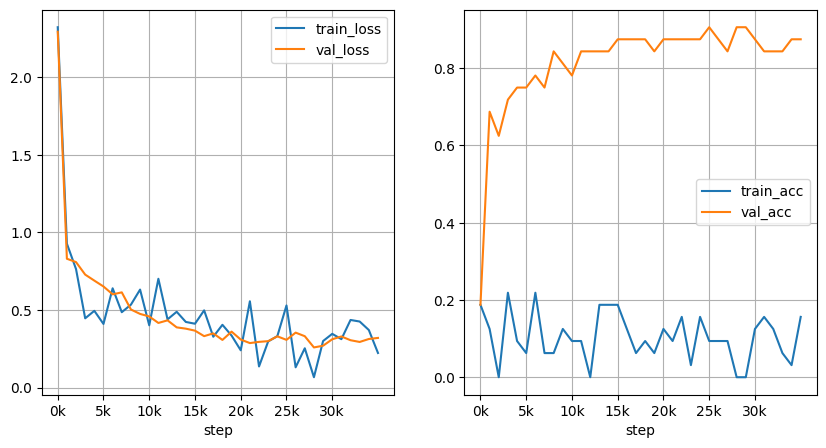

In [176]:
plot_learning_curves(record)  #横坐标是 steps

# 评估

In [177]:
model = NeuralNetwork()  # 上线时加载模型
model = model.to(device)

In [179]:
# 加载模型权重
# 加载最好模型权重
model.load_state_dict(torch.load("checkpoints/best_model.ckpt", map_location="cpu", weights_only=True))

model.eval()  # 进入评估模式
loss, acc = evaluator(model, val_lorder, loss_fct)
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.2702
accuracy: 0.9062
